# Regularization Techniques: Ridge and Lasso Regression

##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: Feb 15, 2026
##### Video Link: https://youtu.be/aBjub5B2v4g

---

This assignment walks through ridge and lasso regression: what they are, how they differ from regular linear regression, and how to use them on real data. We compare models using R², RMSE, AIC, and BIC.

---
# Part 1: Understanding Regularization Techniques

## 1. Explaining Regularization

**What problem does regularization address?**  
Regular linear regression tries to fit the data as closely as possible. Sometimes this causes the model to "memorize" the training data instead of learning general patterns—this is called **overfitting**. When we have many predictors or correlated ones, the model can become unstable. Regularization fixes this by adding a penalty that keeps the coefficients from getting too large.

**How do ridge and lasso achieve this?**
- **Ridge regression**: Penalizes the sum of squared coefficients. It shrinks all coefficients toward zero but usually keeps them non-zero. Think of it as a "gentle" shrinkage.
- **Lasso regression**: Penalizes the sum of absolute values of coefficients. It can shrink some coefficients all the way to zero, effectively removing those predictors from the model. This is called *variable selection*.

## 2. Ridge vs. Lasso Comparison

| Aspect | Ridge | Lasso |
|--------|-------|-------|
| What it penalizes | Squared coefficients | Absolute value of coefficients |
| Effect on coefficients | Shrinks all toward zero | Can set some to exactly zero |
| Variable selection | No | Yes—removes unimportant predictors |
| Use when | You think most predictors matter | You think only some predictors matter |

## 3. Simulated Dataset with 8 Predictors

Create a simulated dataset with X1–X8 and outcome Y, with added noise to mimic real-world data.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Create simulated dataset: 500 rows, 8 predictors (X1 through X8)
n = 500
X_sim = np.random.randn(n, 8)
# We set up true coefficients: some matter (X1, X2, X3), some don't (zeros)
true_betas = np.array([3.0, -1.5, 2.0, 0.0, 0.0, 0.5, 0.0, -0.3])
Y_sim = X_sim @ true_betas + np.random.normal(0, 2, n)  # Add random noise

sim_df = pd.DataFrame(X_sim, columns=[f'X{i+1}' for i in range(8)])
sim_df['Y'] = Y_sim

print("Simulated Dataset Summary:")
print(sim_df.describe())
print("\nTrue coefficients used to generate Y:", true_betas)

Simulated Dataset Summary:
               X1          X2          X3          X4          X5          X6  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean    -0.006962    0.036957   -0.049965    0.043937    0.068210    0.012700   
std      0.997419    1.019014    0.980289    1.012179    0.928691    1.005578   
min     -3.019512   -2.832156   -2.619745   -2.991136   -2.747505   -2.896255   
25%     -0.649690   -0.650418   -0.736320   -0.692542   -0.566601   -0.692685   
50%      0.022553    0.018425   -0.033906    0.068041    0.076662    0.023017   
75%      0.647776    0.717703    0.604116    0.723863    0.680003    0.655707   
max      2.526932    3.852731    2.949094    2.759660    3.243093    3.137749   

               X7          X8           Y  
count  500.000000  500.000000  500.000000  
mean     0.033455    0.016236   -0.362839  
std      1.030510    1.002544    4.413831  
min     -3.241267   -2.921350  -17.924533  
25%     -0.605937   -0.

## 4 & 5. Fit Three Models and Interpret Coefficients

We fit three models: regular linear regression (OLS), ridge, and lasso. We scale the data first so ridge and lasso treat all predictors fairly.

In [3]:
# Scale the data (required for ridge and lasso)
X_sim_scaled = StandardScaler().fit_transform(X_sim)
y_sim = sim_df['Y'].values

# Fit the three models
lm_ols = LinearRegression().fit(X_sim_scaled, y_sim)
lm_ridge = Ridge(alpha=1.0).fit(X_sim_scaled, y_sim)
lm_lasso = Lasso(alpha=0.5).fit(X_sim_scaled, y_sim)

# Compare coefficients
coef_df = pd.DataFrame({
    'Variable': [f'X{i+1}' for i in range(8)],
    'OLS': lm_ols.coef_,
    'Ridge': lm_ridge.coef_,
    'Lasso': lm_lasso.coef_
})
print("Coefficient Comparison (Simulated Data):")
print(coef_df.to_string(index=False))

Coefficient Comparison (Simulated Data):
Variable       OLS     Ridge     Lasso
      X1  2.954404  2.948378  2.455521
      X2 -1.526501 -1.523675 -1.081174
      X3  1.997392  1.993399  1.491175
      X4 -0.034644 -0.034787 -0.000000
      X5 -0.094047 -0.093638 -0.000000
      X6  0.533483  0.532396  0.039375
      X7  0.048798  0.048684  0.000000
      X8 -0.265595 -0.265536 -0.000000


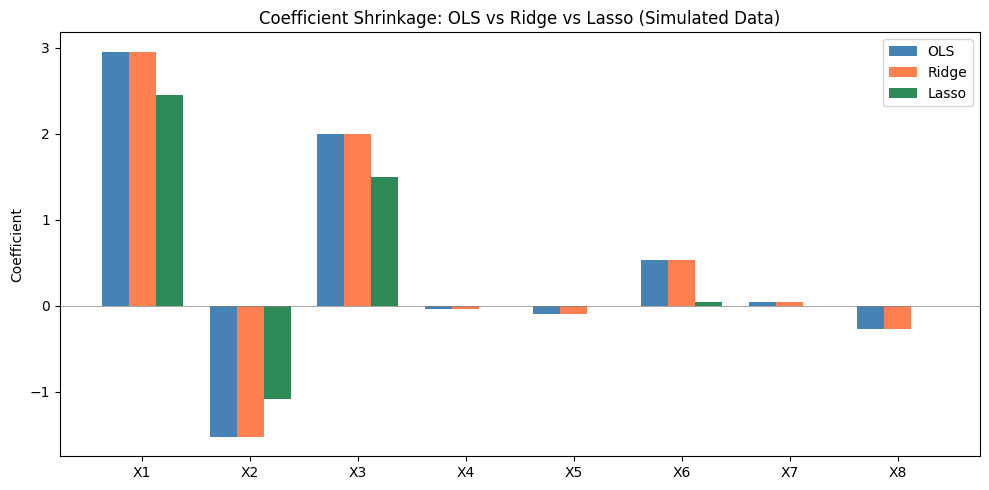

In [4]:
# Visualize coefficient shrinkage
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(coef_df))
width = 0.25
ax.bar(x - width, coef_df['OLS'], width, label='OLS', color='steelblue')
ax.bar(x, coef_df['Ridge'], width, label='Ridge', color='coral')
ax.bar(x + width, coef_df['Lasso'], width, label='Lasso', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(coef_df['Variable'])
ax.set_ylabel('Coefficient')
ax.set_title('Coefficient Shrinkage: OLS vs Ridge vs Lasso (Simulated Data)')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation:**  
- **OLS** (regular regression) gives coefficients with no penalty—they can be large.
- **Ridge** shrinks all coefficients toward zero but none become exactly zero.
- **Lasso** pushes some coefficients to zero (e.g., X4, X7)—those predictors are effectively removed from the model.

---
# Part 2: Applying Regularization to a Real-World Dataset

## Housing Prices Dataset

Load the housing dataset with: Price, Size, Bedrooms, Age, Distance_to_city_center, Lot_size, Bathrooms, Garage, Year_built.

In [5]:
# Load housing dataset
housing = pd.read_csv('data/housing_prices.csv')
print("Housing Dataset Shape:", housing.shape)
print("\nFirst few rows:")
display(housing.head())
print("\nSummary:")
display(housing.describe())

Housing Dataset Shape: (4140, 9)

First few rows:


,Price,Size,Bedrooms,Year_built,Age,Lot_size,Bathrooms,Distance_to_city_center,Garage
0,376000.0,1340,3,2008,18,1384,2.00,6.766942,0
1,800000.0,3540,4,2007,19,159430,3.25,36.471207,1
2,2238888.0,7270,5,2010,16,130017,6.50,32.946466,1
3,324000.0,998,3,2007,19,904,2.25,9.749890,0
4,549900.0,3060,5,1979,47,7015,2.75,5.700540,1



Summary:


,Price,Size,Bedrooms,Year_built,Age,Lot_size,Bathrooms,Distance_to_city_center,Garage
count,4.140000e+03,4140.000000,4140.000000,4140.000000,4140.000000,4.140000e+03,4140.000000,4140.000000,4140.000000
mean,5.530629e+05,2143.638889,3.400483,1970.814010,55.185990,1.469764e+04,2.163043,7.904322,0.690821
std,5.836865e+05,957.481621,0.903939,29.807941,29.807941,3.587684e+04,0.784733,6.197443,0.462211
min,0.000000e+00,370.000000,0.000000,1900.000000,12.000000,6.380000e+02,0.000000,1.000000,0.000000
25%,3.200000e+05,1470.000000,3.000000,1951.000000,29.000000,5.000000e+03,1.750000,4.730292,0.000000
50%,4.600000e+05,1980.000000,3.000000,1976.000000,50.000000,7.676000e+03,2.250000,7.007865,1.000000
75%,6.591250e+05,2620.000000,4.000000,1997.000000,75.000000,1.100000e+04,2.500000,9.402088,1.000000
max,2.659000e+07,10040.000000,8.000000,2014.000000,126.000000,1.074218e+06,6.750000,50.000000,1.000000


In [6]:
# Prepare housing data: X and y
feature_cols = ['Size', 'Bedrooms', 'Age', 'Distance_to_city_center', 'Lot_size', 'Bathrooms', 'Garage', 'Year_built']
X = housing[feature_cols]
y = housing['Price']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (required for ridge/lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit OLS for comparison
ols_housing = LinearRegression().fit(X_train_scaled, y_train)

## Ridge Regression: Tune λ via Cross-Validation

We use cross-validation to pick the best value of λ (called alpha in sklearn). The model tries different λ values and picks the one that gives the best average fit across 5 folds.

In [7]:
# Ridge regression with cross-validation to select optimal λ
alphas = np.logspace(-4, 4, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error').fit(X_train_scaled, y_train)
ridge_optimal_lambda = ridge_cv.alpha_
print(f"Best λ for Ridge: {ridge_optimal_lambda:.6f}")
print("This value was chosen by 5-fold cross-validation.")

Best λ for Ridge: 54.622772
This value was chosen by 5-fold cross-validation.


In [8]:
# Compare OLS vs Ridge coefficients (housing)
ridge_coef = ridge_cv.coef_
coef_housing = pd.DataFrame({
    'Variable': feature_cols,
    'OLS': ols_housing.coef_,
    'Ridge': ridge_coef
})
print("OLS vs Ridge Coefficients (Housing):")
print(coef_housing.to_string(index=False))
print("\nNotice how Ridge coefficients are smaller than OLS—they are shrunk toward zero.")

OLS vs Ridge Coefficients (Housing):
               Variable           OLS         Ridge
                   Size 288218.219463 275888.030610
               Bedrooms -68960.483497 -63366.944953
                    Age  37086.420466  36559.720011
Distance_to_city_center -27181.519971 -24851.520864
               Lot_size  -4882.759943  -5197.752392
              Bathrooms  53532.541181  58270.110114
                 Garage  -4423.342646  -4428.456460
             Year_built -37086.420466 -36559.720011

Notice how Ridge coefficients are smaller than OLS—they are shrunk toward zero.


## Lasso Regression: Tune λ via Cross-Validation

Same idea as Ridge: we use cross-validation to find the best λ (alpha).

In [9]:
# Lasso regression with cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5).fit(X_train_scaled, y_train)
lasso_optimal_lambda = lasso_cv.alpha_
print(f"Best λ for Lasso: {lasso_optimal_lambda:.6f}")
print("This value was chosen by 5-fold cross-validation.")

Best λ for Lasso: 3274.549163
This value was chosen by 5-fold cross-validation.


In [10]:
# Compare Ridge vs Lasso coefficients
coef_ridge_lasso = pd.DataFrame({
    'Variable': feature_cols,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
})
print("Ridge vs Lasso Coefficients (Housing):")
print(coef_ridge_lasso.to_string(index=False))
zero_vars = coef_ridge_lasso[coef_ridge_lasso['Lasso'] == 0]['Variable'].tolist()
print(f"\nVariables set to zero by Lasso: {zero_vars if zero_vars else 'None'}")
print("When Lasso sets a coefficient to zero, that predictor is removed from the model.")

Ridge vs Lasso Coefficients (Housing):
               Variable         Ridge         Lasso
                   Size 275888.030610 281490.288610
               Bedrooms -63366.944953 -59550.411820
                    Age  36559.720011  47358.209228
Distance_to_city_center -24851.520864 -24321.604475
               Lot_size  -5197.752392  -2913.358678
              Bathrooms  58270.110114  46109.353899
                 Garage  -4428.456460  -1385.408452
             Year_built -36559.720011 -19905.723080

Variables set to zero by Lasso: None
When Lasso sets a coefficient to zero, that predictor is removed from the model.


## Model Performance: AIC and BIC

**AIC** (Akaike Information Criterion) and **BIC** (Bayesian Information Criterion) measure how well a model fits the data while penalizing complexity. **Lower is better.** A simpler model that fits almost as well will have a lower AIC/BIC.

In [11]:
def compute_aic_bic(y_true, y_pred, n_params):
    """Compute AIC and BIC. n_params = number of predictors + 1 (intercept)."""
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    aic = n * np.log(rss / n) + 2 * n_params
    bic = n * np.log(rss / n) + n_params * np.log(n)
    return aic, bic

# Get predictions on test set
y_pred_ols = ols_housing.predict(X_test_scaled)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

# For AIC/BIC: count predictors + 1 for intercept. Lasso uses fewer if it sets some to zero.
p = X_train.shape[1]
n_params_ols = p + 1
n_params_ridge = p + 1
n_params_lasso = np.sum(lasso_cv.coef_ != 0) + 1

aic_ols, bic_ols = compute_aic_bic(y_test, y_pred_ols, n_params_ols)
aic_ridge, bic_ridge = compute_aic_bic(y_test, y_pred_ridge, n_params_ridge)
aic_lasso, bic_lasso = compute_aic_bic(y_test, y_pred_lasso, n_params_lasso)

print("AIC (lower is better):")
print(f"  OLS:   {aic_ols:.2f}")
print(f"  Ridge: {aic_ridge:.2f}")
print(f"  Lasso: {aic_lasso:.2f}")
print("\nBIC (lower is better):")
print(f"  OLS:   {bic_ols:.2f}")
print(f"  Ridge: {bic_ridge:.2f}")
print(f"  Lasso: {bic_lasso:.2f}")

AIC (lower is better):
  OLS:   20667.34
  Ridge: 20658.58
  Lasso: 20661.50

BIC (lower is better):
  OLS:   20709.81
  Ridge: 20701.05
  Lasso: 20703.97


**Discussion:** Lower AIC/BIC is better. If Lasso gets similar predictions with fewer predictors, it may have lower AIC/BIC. Both metrics reward good fit but penalize using too many predictors—so a simpler model can win even if it fits slightly worse.

---
# Part 3: Model Selection and Interpretation

## 1. Comparison Table

Create a table comparing OLS, Ridge, and Lasso in terms of coefficients, AIC, BIC, R², and RMSE.

In [12]:
# Compute R² and RMSE
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_ols = r2_score(y_test, y_pred_ols)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Summary table
summary = pd.DataFrame({
    'Metric': ['AIC', 'BIC', 'R²', 'RMSE'],
    'OLS': [aic_ols, bic_ols, r2_ols, rmse_ols],
    'Ridge': [aic_ridge, bic_ridge, r2_ridge, rmse_ridge],
    'Lasso': [aic_lasso, bic_lasso, r2_lasso, rmse_lasso]
})
print("Model Comparison Summary:")
display(summary)

Model Comparison Summary:


,Metric,OLS,Ridge,Lasso
0,AIC,20667.340912,20658.577434,20661.502309
1,BIC,20709.812031,20701.048553,20703.973427
2,R²,0.353925,0.360727,0.358465
3,RMSE,260252.804699,258879.196252,259336.840078


In [13]:
# Full coefficient comparison table
print("Coefficient Comparison (all three models):")
display(coef_housing.assign(Lasso=lasso_cv.coef_))

Coefficient Comparison (all three models):


,Variable,OLS,Ridge,Lasso
0,Size,288218.219463,275888.030610,281490.288610
1,Bedrooms,-68960.483497,-63366.944953,-59550.411820
2,Age,37086.420466,36559.720011,47358.209228
3,Distance_to_city_center,-27181.519971,-24851.520864,-24321.604475
4,Lot_size,-4882.759943,-5197.752392,-2913.358678
5,Bathrooms,53532.541181,58270.110114,46109.353899
6,Garage,-4423.342646,-4428.456460,-1385.408452
7,Year_built,-37086.420466,-36559.720011,-19905.723080


## 2. Residual Plots

Visualize model fit via residual plots.

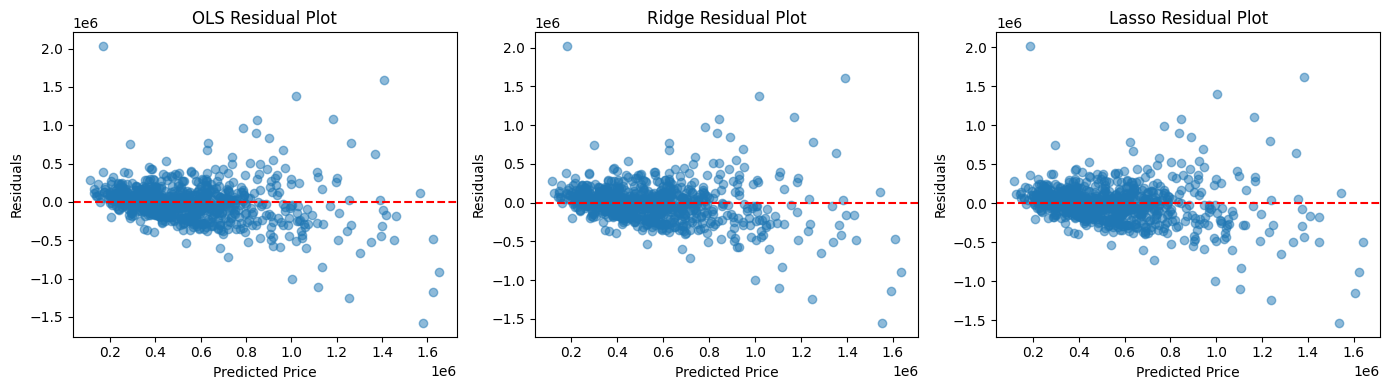

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred in zip(axes, ['OLS', 'Ridge', 'Lasso'], 
                          [y_pred_ols, y_pred_ridge, y_pred_lasso]):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.5)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} Residual Plot')
plt.tight_layout()
plt.show()

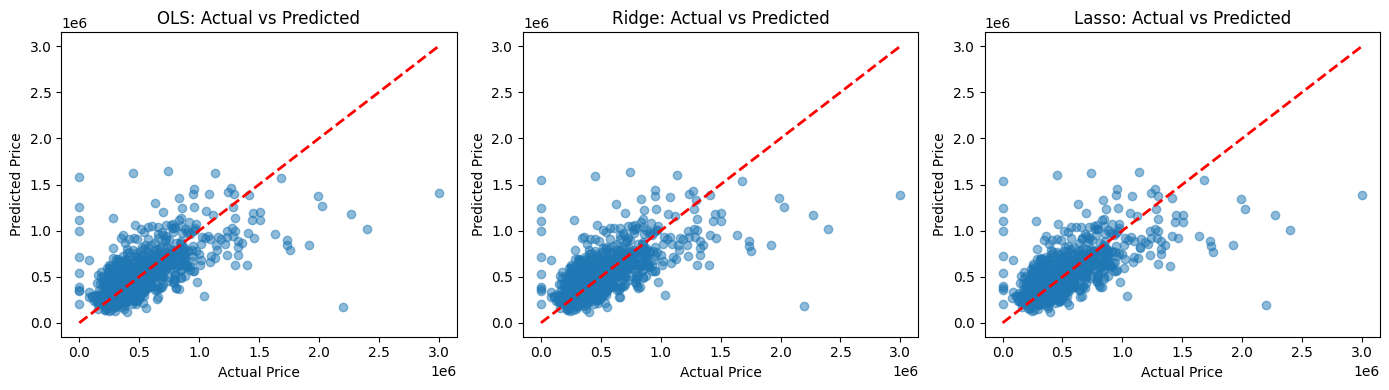

In [15]:
# Scatter: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred in zip(axes, ['OLS', 'Ridge', 'Lasso'], 
                          [y_pred_ols, y_pred_ridge, y_pred_lasso]):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}: Actual vs Predicted')
plt.tight_layout()
plt.show()

## 3. Final Recommendation

**Interpretation:**  
- **OLS** can overfit when predictors are correlated; coefficients may be unstable.
- **Ridge** shrinks coefficients, which often improves stability on new data.
- **Lasso** can remove unimportant predictors, giving a simpler model.

**Recommendation:**  
Look at the table above. The best model is the one with the lowest AIC, lowest BIC, highest R², and lowest RMSE. If two models are close, prefer the simpler one (fewer predictors). Often Ridge or Lasso will perform better than OLS on unseen data.

In [16]:
# Which model performed best?
print("Best model by AIC (lower is better):", min([('OLS', aic_ols), ('Ridge', aic_ridge), ('Lasso', aic_lasso)], key=lambda x: x[1])[0])
print("Best model by BIC (lower is better):", min([('OLS', bic_ols), ('Ridge', bic_ridge), ('Lasso', bic_lasso)], key=lambda x: x[1])[0])
print("Best model by RMSE (lower is better):", min([('OLS', rmse_ols), ('Ridge', rmse_ridge), ('Lasso', rmse_lasso)], key=lambda x: x[1])[0])
print("Best model by R² (higher is better):", max([('OLS', r2_ols), ('Ridge', r2_ridge), ('Lasso', r2_lasso)], key=lambda x: x[1])[0])
print(f"\nLasso kept {np.sum(lasso_cv.coef_ != 0)} of {p} predictors (the rest were set to zero).")

Best model by AIC (lower is better): Ridge
Best model by BIC (lower is better): Ridge
Best model by RMSE (lower is better): Ridge
Best model by R² (higher is better): Ridge

Lasso kept 8 of 8 predictors (the rest were set to zero).
